# Comparison of SVM and Deep Learning Models

Best possible SVM (whichever of `3.2a`'s direct model or `3.2b`'s residual-on-baseline model wins)
vs. neural network, compared at `h3_7/daily`. **The whole comparison — model selection, the metrics
table, the spatial error maps, calibration, and the day-of-week / demand-segment breakdowns — runs
on the validation split.** The held-out **test** split is scored exactly once, in the final cell,
for the model(s) already chosen on validation. This keeps the test set a genuine one-time holdout
rather than something the comparison is tuned against. The choropleth helpers are reused from
`2.3 TempHexagonVis.ipynb`.

**Both inputs are optional.** There is currently no NN trained on the current `h3_7/daily` split
(only stale hourly `res7` checkpoints on the pre-rebuild pipeline exist in
`models_predictions/ANN/`), so every cell below runs with whichever of the SVM / NN is actually
available: missing a model just means fewer panels on each map and one fewer row in the tables,
not a crash. The one exception is the SVM-vs-NN difference map, which needs both to mean anything
and is skipped with a printed note if only one model is present.

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h3
import joblib
import geopandas as gpd
import contextily as ctx
import shapely
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore", category=UserWarning)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SPATIAL, TEMPORAL = "h3_7", "daily"
TARGET = "Total_Trip_Start"
SPLIT_DIR = Path("..") / "data" / "prediction_split"
MODELS_DIR = Path("..") / "models_predictions"
SVR_DIR = MODELS_DIR / "SVR" / "standard" / "models"
SVR_RESIDUAL_DIR = MODELS_DIR / "SVR" / "residual" / "models"
NN_DIR = MODELS_DIR / "ANN" / "standard" / "models"
LOG_CEILING = 20.0

# The comparison runs on validation; test is scored once at the very end.
df_val = pd.read_parquet(SPLIT_DIR / SPATIAL / TEMPORAL / "val.parquet")
df_test = pd.read_parquet(SPLIT_DIR / SPATIAL / TEMPORAL / "test.parquet")

## Loading the best SVM and the neural network

"Best possible SVM" is computed, not assumed: both the direct (`3.2a`) and residual-on-baseline
(`3.2b`) bundles for `h3_7/daily` are loaded if they exist, scored on the **validation** split, and
whichever wins becomes `svm_bundle`. If neither is found, the SVM is simply left out. Selecting on
validation (not test) is what lets the final cell report an untouched test number.

The neural network is expected at `models_predictions/ANN/standard/models/h3_7/daily/best.joblib`,
a joblib dict with the same `features`/`scaler`/`target`/`transform` fields as the SVR bundles plus
a `hidden_layers` list and a torch `state_dict`, so `predict_nn_bundle` below can reconstruct the
architecture and load its weights without re-running any training notebook:

```
{"state_dict": ..., "hidden_layers": [...], "features": [...], "scaler": ...,
 "target": "Total_Trip_Start", "transform": "log1p", "val_metrics": {...}, "test_metrics": {...}}
```

Both loads are wrapped so a missing file is skipped (with a printed note) rather than raising --
every cell below adapts to however many of the two models actually loaded, via the shared
`predictions` dict built here.

In [2]:
def to_counts(pred_log):
    return np.clip(np.expm1(np.clip(pred_log, -LOG_CEILING, LOG_CEILING)), 0, None)


def score(y_true, pred, name):
    return {"Model": name,
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
            "R2": r2_score(y_true, pred)}


def predict_bundle(bundle, df):
    """Predict demand counts from an SVR bundle, whether it is a direct (3.2a) or
    residual-on-baseline (3.2b) model -- dispatches on bundle["target"]."""
    X = bundle["scaler"].transform(df[bundle["features"]])
    log1p_pred = bundle["model"].predict(X)
    if bundle["target"] == "residual_log1p_over_base_demand":
        log1p_pred = log1p_pred + np.log1p(df["base_demand"].values)
    return to_counts(log1p_pred)


def try_load_bundle(path):
    try:
        return joblib.load(path)
    except FileNotFoundError:
        return None


# Model selection and every comparison below run on validation.
y_eval = df_val[TARGET].values
predictions = {}  # key -> {"col": prediction column name, "name": display name for titles/legends}

direct = try_load_bundle(SVR_DIR / SPATIAL / TEMPORAL / "best.joblib")
residual = try_load_bundle(SVR_RESIDUAL_DIR / SPATIAL / TEMPORAL / "best.joblib")

svm_candidates = {}
if direct is not None:
    svm_candidates[f"Direct SVR ({direct['feature_set']}, {direct['kernel']})"] = (direct, predict_bundle(direct, df_val))
if residual is not None:
    svm_candidates[f"Residual SVR ({residual['feature_set']}, {residual['kernel']})"] = (residual, predict_bundle(residual, df_val))

svm_bundle = None
if svm_candidates:
    svm_name = max(svm_candidates, key=lambda n: r2_score(y_eval, svm_candidates[n][1]))
    svm_bundle, pred_svm = svm_candidates[svm_name]
    df_val["pred_svm"] = pred_svm
    predictions["svm"] = {"col": "pred_svm", "name": f"Best SVM ({svm_name})"}
    print(f"Best possible SVM at {SPATIAL}/{TEMPORAL} (chosen on validation): {svm_name}")
else:
    print(f"No SVM bundle found at {SVR_DIR / SPATIAL / TEMPORAL} or {SVR_RESIDUAL_DIR / SPATIAL / TEMPORAL} -- skipping the SVM side.")

Best possible SVM at h3_7/daily (chosen on validation): Residual SVR (basic, rbf)


In [ ]:
class FNN(nn.Module):
    def __init__(self, input_size, hidden_layers, dropout_rate):
        super(FNN, self).__init__()
        self.layers = nn.ModuleList()
        self.dropouts = nn.ModuleList()
        prev_size = input_size
        for hidden_size in hidden_layers:
            self.layers.append(nn.Linear(prev_size, hidden_size))
            self.dropouts.append(nn.Dropout(p=dropout_rate))
            prev_size = hidden_size
        self.output_layer = nn.Linear(prev_size, 1)

    def forward(self, x):
        for i in range(len(self.layers)):
            x = F.relu(self.layers[i](x))
            x = self.dropouts[i](x)
        return self.output_layer(x).squeeze(1)


def predict_nn_bundle(bundle, df):
    """Mirrors predict_bundle above for a torch FNN bundle: reconstruct the architecture from
    hidden_layers, load its weights, scale inputs with the bundle's own scaler, and invert the
    log1p transform."""
    device = torch.device("cuda" if torch.cuda.is_available()
                          else "mps" if torch.backends.mps.is_available() else "cpu")
    model = FNN(input_size=len(bundle["features"]), hidden_layers=bundle["hidden_layers"]).to(device)
    model.load_state_dict(bundle["state_dict"])
    model.eval()
    X = bundle["scaler"].transform(df[bundle["features"]])
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        log1p_pred = model(X_t).cpu().numpy()
    return to_counts(log1p_pred)


# None until the h3_7/daily FNN follow-up has been trained and saved in the format documented
# above -- skipped (with a printed note) rather than crashing the rest of the notebook.
nn_bundle = try_load_bundle(NN_DIR / SPATIAL / TEMPORAL / "best.joblib")
if nn_bundle is not None:
    df_val["pred_nn"] = predict_nn_bundle(nn_bundle, df_val)
    predictions["nn"] = {"col": "pred_nn", "name": "Neural Network"}
else:
    print(f"No NN bundle found at {NN_DIR / SPATIAL / TEMPORAL / 'best.joblib'} -- skipping the NN side.")

if not predictions:
    raise RuntimeError("Neither an SVM nor an NN model is available for "
                       f"{SPATIAL}/{TEMPORAL} -- nothing to evaluate.")

No NN bundle found at ../models_predictions/ANN/standard/models/h3_7/daily/best.joblib -- skipping the NN side.


## Performance Metrics Table

Baseline (`base_demand`) plus whichever of the best SVM / the neural network are available,
compared on the full `h3_7/daily` **validation** set. (The one-time test evaluation is the last
cell of the notebook.)

In [4]:
#| label: tbl-svm-vs-nn-overall
#| tbl-cap: "Overall validation performance at h3_7/daily: historical-mean baseline plus whichever of the best possible SVM / the neural network are available. The held-out test set is scored once at the end."
rows = [score(y_eval, df_val["base_demand"].values, "Baseline (base_demand)")]
for p in predictions.values():
    rows.append(score(y_eval, df_val[p["col"]].values, p["name"]))
overall = pd.DataFrame(rows).set_index("Model")
overall.round(4)

,MAE,RMSE,R2
Model,,,
Baseline (base_demand),18.0772,112.6315,0.9234
"Best SVM (Residual SVR (basic, rbf))",14.2474,86.1009,0.9552


## Predicted vs. actual demand

The single-number table hides *how* each model misses. A calibration plot puts predicted against
actual demand on the log1p scale (the scale the models are fit on): points on the `y = x` line are
perfect, points above it are overpredictions and below are underpredictions. It shows at a glance
whether a model is biased high or low, and where in the demand range it struggles.

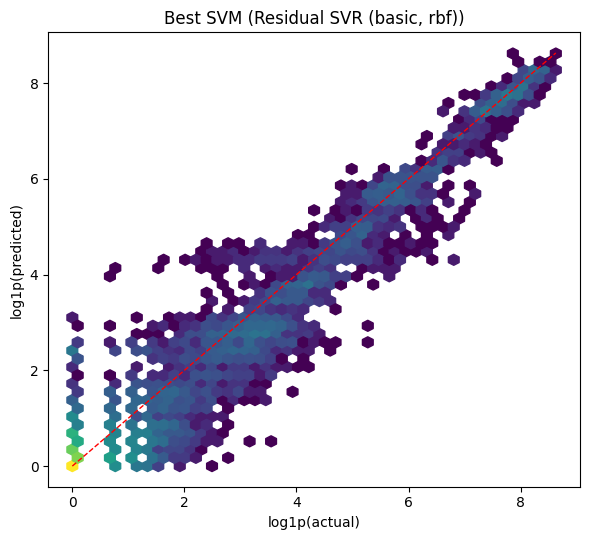

In [5]:
#| label: fig-svm-pred-vs-actual
#| fig-cap: "Predicted vs. actual demand (log1p scale) on the validation set, per available model. The red dashed line is y = x; points above it are overpredictions, below are underpredictions."
models = list(predictions.values())
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5.5), squeeze=False)
y_log = np.log1p(y_eval)
for ax, p in zip(axes[0], models):
    pred_log = np.log1p(df_val[p["col"]].values)
    ax.hexbin(y_log, pred_log, gridsize=45, cmap="viridis", mincnt=1, bins="log")
    lim = max(y_log.max(), pred_log.max())
    ax.plot([0, lim], [0, lim], color="red", linewidth=1, linestyle="--")
    ax.set_title(p["name"])
    ax.set_xlabel("log1p(actual)")
    ax.set_ylabel("log1p(predicted)")
fig.tight_layout()
plt.show()

## Spatial prediction quality

The aggregate metrics above collapse the whole city into a single number and hide strong
**spatial** variation in how well each model performs. Here we aggregate error by H3 hexagon and
compare whichever of the SVM / the neural network are available, side by side.

- **MAE per hexagon** -- the absolute size of the prediction miss (trips/day).
- **Relative error per hexagon** -- the miss size relative to that cell's own mean demand.
- **R² per hexagon** -- how much of each cell's day-to-day demand *variation* the model explains.
  Cells whose demand is essentially flat have no variation to explain, so their R² is undefined
  and they are greyed out.


In [6]:
# Community area outlines, used as a spatial reference overlay in the choropleths. The dedicated
# chicago_community_areas.gpkg file referenced by earlier versions of this notebook does not
# exist -- dissolve the census-tract file by commarea instead, the same fix 3.6b uses.
tracts = gpd.read_file(Path("..") / "data" / "chicago_census_comm.gpkg")
community_areas = tracts.dissolve(by="commarea")


def get_hexagon_grid(data, h3_col="h3_index"):
    """Build a GeoDataFrame of H3 hexagon polygons, preserving all columns from the source."""
    def _to_polygon(cell):
        boundary = h3.cell_to_boundary(cell)
        return shapely.geometry.Polygon([(lng, lat) for lat, lng in boundary])

    if isinstance(data, pd.Series):
        df = pd.DataFrame({"h3_index": list(data)})
        h3_list = df["h3_index"]
    else:
        df = data.reset_index(drop=True)
        h3_list = df[h3_col]
    geometries = [_to_polygon(c) for c in h3_list]
    return gpd.GeoDataFrame(df, geometry=geometries, crs="EPSG:4326")


def get_hexagon_performance_metrics(df_eval, pred_col, target_col=TARGET, h3_col="h3_index_7"):
    """Compute MAE/RMSE/R2/relative-error per hexagon for one prediction column."""
    d = df_eval.assign(
        abs_err=(df_eval[target_col] - df_eval[pred_col]).abs(),
        sq_err=(df_eval[target_col] - df_eval[pred_col]) ** 2,
    )
    grp = d.groupby(h3_col)
    hex_perf = grp.agg(
        n_obs=(target_col, "size"),
        mean_actual=(target_col, "mean"),
        var_actual=(target_col, "var"),
        mae=("abs_err", "mean"),
        mse=("sq_err", "mean"),
    )
    hex_perf["rmse"] = np.sqrt(hex_perf["mse"])
    ss_res = grp["sq_err"].sum()
    ss_tot = hex_perf["var_actual"].fillna(0) * (hex_perf["n_obs"] - 1)
    hex_perf["r2"] = 1 - ss_res / ss_tot.replace(0, np.nan)
    hex_perf["rel_error"] = hex_perf["mae"] / hex_perf["mean_actual"].replace(0, np.nan)
    hex_perf = hex_perf.drop(columns=["var_actual", "mse"]).reset_index()
    hex_perf_gdf = get_hexagon_grid(hex_perf, h3_col=h3_col)
    return hex_perf, hex_perf_gdf


def create_choropleth_plot(ax, gdf, value_col, title="", cmap="YlOrRd", k=7):
    """Plot one quantile choropleth of a hexagon-level metric onto ax, with a Chicago basemap and
    community-area boundary overlay."""
    gdf.to_crs(epsg=3857).plot(
        ax=ax, column=value_col, cmap=cmap, scheme="quantiles", k=k,
        edgecolor="none", alpha=0.8, legend=True, zorder=1,
        legend_kwds=dict(title=value_col.replace("_", " ").title(),
                         loc="lower right", fontsize=8, title_fontsize=9),
        missing_kwds=dict(color="lightgrey", label="No data"),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)


In [7]:
# (hex_perf, hex_gdf) per available model, keyed the same way as `predictions`. Computed on validation.
hex_data = {key: get_hexagon_performance_metrics(df_val, pred_col=p["col"], h3_col="h3_index_7")
           for key, p in predictions.items()}

### Map 1: mean absolute error (MAE) per hexagon

Because demand itself is far higher downtown, the largest absolute errors concentrate in the Loop;
the quiet outskirts have tiny MAE simply because there is little demand.


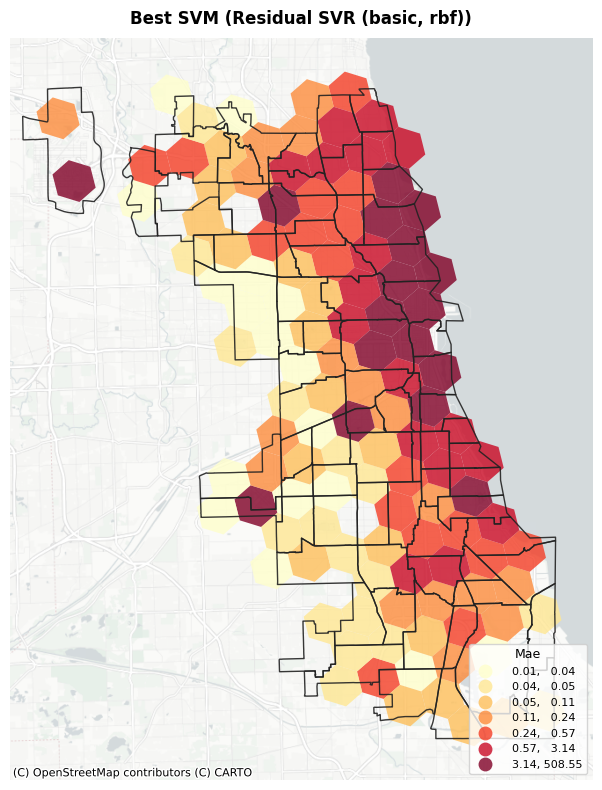

In [8]:
#| label: fig-svm-hex-mae
#| fig-cap: "MAE per hexagon (trips/day), per available model (SVM and/or neural network)."
fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
    create_choropleth_plot(ax, gdf, "mae", title=predictions[key]["name"])
plt.tight_layout()
plt.show()


### Map 2: mean relative error (MRE) per hexagon

The miss size relative to each cell's own mean demand -- this is what makes small-demand
outskirts visible instead of always looking "perfect" on raw MAE alone.


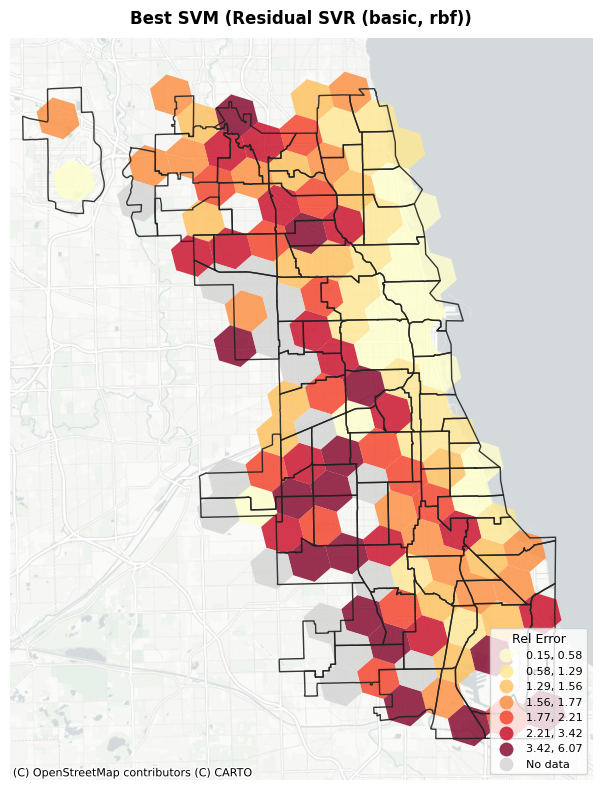

In [9]:
#| label: fig-svm-hex-mre
#| fig-cap: "Relative error per hexagon, per available model (SVM and/or neural network)."
fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
    create_choropleth_plot(ax, gdf, "rel_error", title=predictions[key]["name"])
plt.tight_layout()
plt.show()


### Map 3: coefficient of determination (R2) per hexagon

Green = the day-to-day demand pattern is captured well; red = poorly; grey = too little demand
variation to assess.


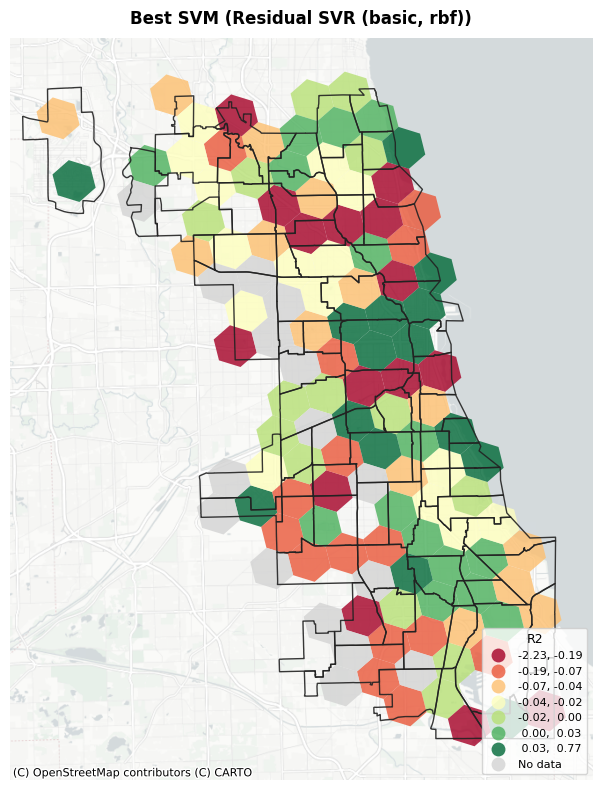

In [10]:
#| label: fig-svm-hex-r2
#| fig-cap: "R² per hexagon, per available model. Green = well predicted, grey = too little demand to assess."
fig, axes = plt.subplots(1, len(hex_data), figsize=(7 * len(hex_data), 8), squeeze=False)
for ax, (key, (_, gdf)) in zip(axes[0], hex_data.items()):
    create_choropleth_plot(ax, gdf, "r2", title=predictions[key]["name"], cmap="RdYlGn")
plt.tight_layout()
plt.show()


### Map 4: where does one model beat the other?

The three maps above put the SVM and the NN side by side, but reading "who wins where" off two
separate color scales is hard. This map plots the difference directly:
`MAE_NN - MAE_SVM` per hexagon. Blue means the SVM has the lower error there (SVM wins); red
means the NN does.


In [11]:
#| label: fig-svm-vs-nn-hex-delta
#| fig-cap: "MAE_NN - MAE_SVM per hexagon. Blue = the SVM wins at that cell; red = the neural network wins."
if "svm" in hex_data and "nn" in hex_data:
    hex_perf_svm, _ = hex_data["svm"]
    hex_perf_nn, _ = hex_data["nn"]
    delta = hex_perf_svm[["h3_index_7", "mae"]].merge(
        hex_perf_nn[["h3_index_7", "mae"]], on="h3_index_7", suffixes=("_svm", "_nn"))
    delta["mae_delta"] = delta["mae_nn"] - delta["mae_svm"]
    delta_gdf = get_hexagon_grid(delta, h3_col="h3_index_7")

    bmax = delta_gdf["mae_delta"].abs().quantile(0.98)  # robust to a handful of extreme outlier cells
    fig, ax = plt.subplots(figsize=(8, 10))
    delta_gdf.to_crs(epsg=3857).plot(
        ax=ax, column="mae_delta", cmap="RdBu_r", vmin=-bmax, vmax=bmax,
        edgecolor="none", alpha=0.85, legend=True, zorder=1,
        legend_kwds=dict(label="MAE_NN - MAE_SVM", shrink=0.6),
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels, zoom=11)
    community_areas.to_crs(epsg=3857).boundary.plot(ax=ax, color="#222", linewidth=1.0, alpha=0.9, zorder=3)
    ax.set_axis_off()
    ax.set_title("Where does the SVM beat the NN, and vice versa?", fontsize=12, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()
else:
    print("Need both an SVM and an NN prediction to plot the difference map -- skipping "
         f"(currently available: {list(hex_data)}).")


Need both an SVM and an NN prediction to plot the difference map -- skipping (currently available: ['svm']).


## Time Performance Analysis

`h3_7/daily` has no hour-of-day feature (each row is already a full day), so the temporal
breakdown here is by day of week only.


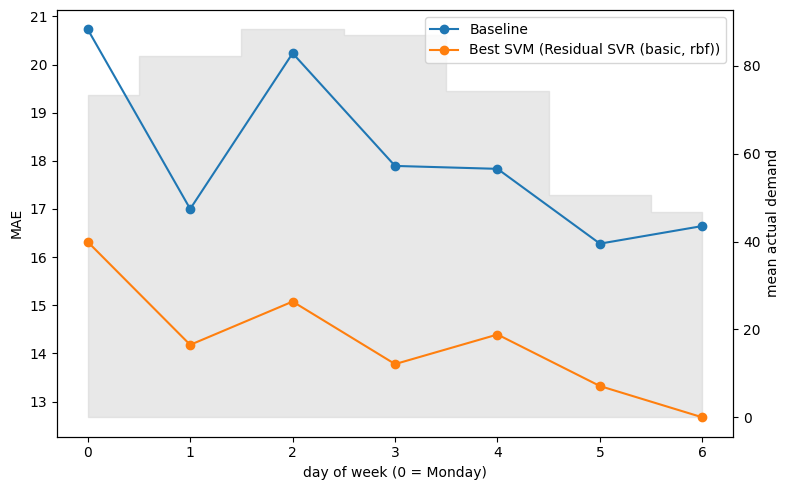

In [12]:
#| label: fig-svm-vs-nn-dayofweek
#| fig-cap: "Validation MAE by day of week: baseline plus whichever of the best SVM / the neural network are available. Gray area is mean actual demand (right axis). 0 = Monday ... 6 = Sunday."
model_cols = ["Baseline"] + [p["name"] for p in predictions.values()]

by_d = df_val.assign(y=y_eval).groupby("day_of_week").apply(
    lambda g: pd.Series({
        "Baseline": mean_absolute_error(g["y"], g["base_demand"]),
        **{p["name"]: mean_absolute_error(g["y"], g[p["col"]]) for p in predictions.values()},
        "mean_demand": g["y"].mean(),
    }), include_groups=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax2 = ax.twinx()
ax2.fill_between(by_d.index, by_d["mean_demand"], color="lightgray", alpha=0.5, step="mid", zorder=0)
ax2.set_ylabel("mean actual demand")
for col in model_cols:
    ax.plot(by_d.index, by_d[col], marker="o", label=col, zorder=2)
ax.set_xlabel("day of week (0 = Monday)")
ax.set_ylabel("MAE")
ax.set_zorder(ax2.get_zorder() + 1)
ax.patch.set_visible(False)
ax.legend()
fig.tight_layout()
plt.show()

## When does each model do best?

The maps above show *where* errors fall; this table shows *when*. It breaks validation MAE down by
demand magnitude (zero / low / medium / high) and by weather (dry vs. rainy days), so a model that
wins overall but loses on, say, the busiest cells or on rainy days is not hidden behind a single
average. The same segmentation `3.6b` uses for the direct-vs-residual comparison.

In [13]:
#| label: tbl-svm-vs-nn-segments
#| tbl-cap: "Validation MAE by demand band and weather: baseline plus whichever of the best SVM / the neural network are available. Highlights where each model does well vs. poorly."
df_val["is_rainy"] = (df_val["total_precip_mm"] >= 0.1).astype(int)


def segment_masks(df, y):
    return {
        "all": np.ones(len(df), dtype=bool),
        "zero demand (y = 0)": y == 0,
        "low demand (1-10)": (y >= 1) & (y <= 10),
        "medium demand (11-100)": (y > 10) & (y <= 100),
        "high demand (> 100)": y > 100,
        "dry days": df["is_rainy"].values == 0,
        "rainy days": df["is_rainy"].values == 1,
    }


rows = []
for seg_name, mask in segment_masks(df_val, y_eval).items():
    if mask.sum() == 0:
        continue
    rows.append({"segment": seg_name, "Model": "Baseline", "n": int(mask.sum()),
                 "MAE": mean_absolute_error(y_eval[mask], df_val["base_demand"].values[mask])})
    for p in predictions.values():
        rows.append({"segment": seg_name, "Model": p["name"], "n": int(mask.sum()),
                     "MAE": mean_absolute_error(y_eval[mask], df_val[p["col"]].values[mask])})

segments = pd.DataFrame(rows).set_index(["segment", "Model"])
segments.round(3)

n      MAE
segment                Model                                               
all                    Baseline                              20587   18.077
                       Best SVM (Residual SVR (basic, rbf))  20587   14.247
zero demand (y = 0)    Baseline                              15938    0.171
                       Best SVM (Residual SVR (basic, rbf))  15938    0.179
low demand (1-10)      Baseline                               2182    2.705
                       Best SVM (Residual SVR (basic, rbf))   2182    2.520
medium demand (11-100) Baseline                               1265   19.070
                       Best SVM (Residual SVR (basic, rbf))   1265   16.827
high demand (> 100)    Baseline                               1202  282.362
                       Best SVM (Residual SVR (basic, rbf))   1202  219.358
dry days               Baseline                              18088   18.223
                       Best SVM (Residual SVR (basic, rbf))  18088   14.279
rainy days             Baseline                               2499   17.025
                       Best SVM (Residual SVR (basic, rbf))   2499   14.019

## One-time test evaluation

Everything above is on validation. Here — and only here — the model(s) already selected on
validation are scored once on the held-out **test** split, so this number is an honest estimate of
out-of-sample performance rather than something the comparison was optimized against.

In [14]:
#| label: tbl-svm-vs-nn-test
#| tbl-cap: "One-time held-out TEST performance at h3_7/daily of the model(s) selected on validation above. The test set is touched only in this cell."
y_test = df_test[TARGET].values
rows = [score(y_test, df_test["base_demand"].values, "Baseline (base_demand)")]
if "svm" in predictions:
    rows.append(score(y_test, predict_bundle(svm_bundle, df_test), predictions["svm"]["name"]))
if "nn" in predictions:
    rows.append(score(y_test, predict_nn_bundle(nn_bundle, df_test), predictions["nn"]["name"]))
final_test = pd.DataFrame(rows).set_index("Model")
final_test.round(4)

,MAE,RMSE,R2
Model,,,
Baseline (base_demand),22.0992,127.7195,0.8998
"Best SVM (Residual SVR (basic, rbf))",19.1517,113.5153,0.9208


In [1]:
#| label: fig-svm-vs-nn-scatter
#| fig-cap: "Actual vs. predicted demand as a scatter plot."
fig, axes = plt.subplots(1, len(predictions), figsize=(6 * len(predictions), 5), squeeze=False)

for ax, (key, p) in zip(axes[0], predictions.items()):
    pred = df_test[p["col"]].values
    lim = max(y_test.max(), pred.max())

    ax.scatter(y_test, pred, alpha=0.3, s=5)
    ax.plot([0, lim], [0, lim], "r--", label="Perfect prediction")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(p["name"])
    ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
#| label: fig-svm-vs-nn-timeseries
#| fig-cap: "Daily demand over the test period as a time series: actual vs. predicted."
df_test["date"] = pd.to_datetime(df_test["timestamp"]).dt.date

daily_agg = df_test.assign(y=y_test).groupby("date").agg(
    actual=("y", "sum"),
    baseline=("base_demand", "sum"),
).reset_index()

for p in predictions.values():
    daily_agg[p["name"]] = df_test.groupby("date")[p["col"]].sum().values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_agg["date"], daily_agg["actual"], label="Actual", color="black", linewidth=1.2)
ax.plot(daily_agg["date"], daily_agg["baseline"], label="Baseline", linestyle="--", color="gray")
for p in predictions.values():
    ax.plot(daily_agg["date"], daily_agg[p["name"]], label=p["name"], linestyle="--")
ax.set_xlabel("Date")
ax.set_ylabel("Total trips")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Verdict

<!-- TODO fill in once models_predictions/ANN/standard/models/h3_7/daily/best.joblib exists and
this notebook can run end-to-end with both models. Points to check:
- Overall: does the NN beat the best SVM on validation (tbl-svm-vs-nn-overall), and does the ranking
  still hold on the one-time test evaluation (tbl-svm-vs-nn-test)?
- By segment: where does each model do best/worst across demand bands and dry/rainy days
  (tbl-svm-vs-nn-segments)?
- Spatially: where does fig-svm-vs-nn-hex-delta show the NN winning vs. the SVM winning -- is it
  concentrated downtown, in the sparse outskirts, or spread evenly?
- Temporally: does either model handle weekends vs. weekdays differently
  (fig-svm-vs-nn-dayofweek)?
- Update sections/04-demand-prediction.qmd's Model Comparison section with the outcome. -->
